# VI vs MCMC

## Сравнительный анализ MCMC и Variational Inference для GMM

Задача: на практике изучить сильные и слабые стороны MCMC (алгоритм NUTS) и Вариационного вывода (SVI), а также научиться бороться с типичными проблемами VI: локальными минимумами, вложенными кластерами и плохой инициализацией.

### Данные

1. Кластер A: широкий, изотропный, круглый.
2. Кластер B: сильно вытянутый, анизотропный по диагонали.
3. Кластер C: узкий круглый пик, расположенный близко к центру кластера B.


In [1]:
import math
import time
import warnings

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, MCMC, NUTS, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal, init_to_median, init_to_value
from pyro.optim import ClippedAdam

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

warnings.filterwarnings("ignore")
pyro.set_rng_seed(42)
torch.set_default_dtype(torch.float32)


C:\Users\пк\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


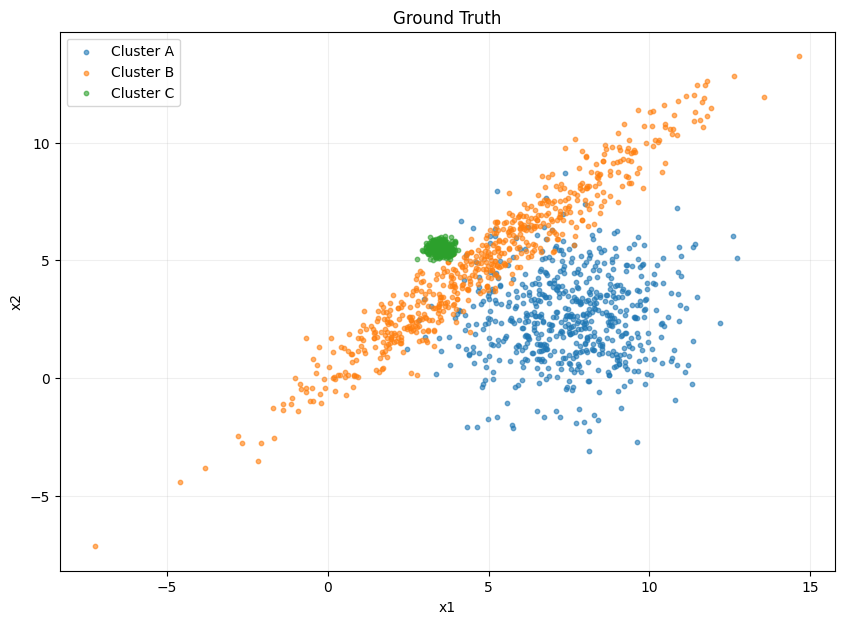

In [2]:
def generate_complex_gmm_data_with_labels(n_samples=1500):
    torch.manual_seed(42)

    # 1. Кластер A: широкий круглый, n=600
    loc_a = torch.tensor([7.5, 2.5])
    data_a = torch.randn(600, 2) * 1.8 + loc_a
    labels_a = torch.zeros(600, dtype=torch.long)

    # 2. Кластер B: вытянутый по диагонали, n=600
    loc_b = torch.tensor([5.0, 5.0])
    scale_b = torch.tensor([4.5, 0.6])
    theta = torch.tensor(math.pi / 4)
    rot = torch.tensor([[theta.cos(), -theta.sin()], [theta.sin(), theta.cos()]])
    data_b = (torch.randn(600, 2) * scale_b) @ rot.T + loc_b
    labels_b = torch.ones(600, dtype=torch.long)

    # 3. Кластер C: узкий пик рядом с центром B, n=300
    loc_c = torch.tensor([3.5, 5.5])
    data_c = torch.randn(300, 2) * 0.2 + loc_c
    labels_c = torch.ones(300, dtype=torch.long) * 2

    data = torch.cat([data_a, data_b, data_c])
    labels = torch.cat([labels_a, labels_b, labels_c])
    idx = torch.randperm(n_samples)
    return data[idx], labels[idx]


data_2d, true_labels = generate_complex_gmm_data_with_labels()

plt.figure(figsize=(10, 7))
for i, name in enumerate(["A", "B", "C"]):
    mask = true_labels == i
    plt.scatter(data_2d[mask, 0], data_2d[mask, 1], s=10, alpha=0.6, label=f"Cluster {name}")
plt.title("Ground Truth")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 1. Variational Inference

Сначала реализуем две модели:

- **Mean Field / diagonal covariance**: компоненты смеси имеют диагональную ковариацию, guide — `AutoDiagonalNormal`.
- **Full Rank / full covariance**: компоненты смеси имеют полную матрицу ковариации через `LKJCholesky`, guide — `AutoMultivariateNormal`.

Для обеих моделей сравниваются два типа инициализации:

1. дефолтная `init_to_median`;
2. K-means инициализация, где центры K-means используются как начальные значения средних компонент.


In [3]:
def model_mf(data, K=3, alpha=1.0):
    D = data.shape[1]
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K) * alpha))

    with pyro.plate("components", K):
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 10.0).to_event(1))
        scales = pyro.sample("scales", dist.LogNormal(torch.zeros(D), 1.0).to_event(1)) + 1e-3

    mixing_dist = dist.Categorical(probs=weights)
    component_dist = dist.Independent(dist.Normal(locs, scales), 1)
    mixture = dist.MixtureSameFamily(mixing_dist, component_dist)

    with pyro.plate("data", data.shape[0]):
        pyro.sample("obs", mixture, obs=data)


def model_fr(data, K=3, alpha=1.0):
    D = data.shape[1]
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K) * alpha))

    with pyro.plate("components", K):
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 10.0).to_event(1))
        scales = pyro.sample("scales", dist.LogNormal(torch.zeros(D), 1.0).to_event(1)) + 1e-3
        corr_cholesky = pyro.sample("corr_cholesky", dist.LKJCholesky(D, concentration=1.0))
        scale_tril = torch.matmul(torch.diag_embed(scales), corr_cholesky)

    mixing_dist = dist.Categorical(probs=weights)
    component_dist = dist.MultivariateNormal(locs, scale_tril=scale_tril)
    mixture = dist.MixtureSameFamily(mixing_dist, component_dist)

    with pyro.plate("data", data.shape[0]):
        pyro.sample("obs", mixture, obs=data)


In [4]:
def kmeans_initial_values(data, K=3, full_cov=False, alpha=1.0, seed=42):
    km = KMeans(n_clusters=K, random_state=seed, n_init=20).fit(data.detach().cpu().numpy())
    labels = torch.tensor(km.labels_, dtype=torch.long)
    centers = torch.tensor(km.cluster_centers_, dtype=data.dtype)
    D = data.shape[1]

    counts = torch.bincount(labels, minlength=K).float()
    weights = (counts + alpha) / (counts.sum() + K * alpha)

    global_std = data.std(dim=0).clamp_min(0.2)
    scales = []
    covs = []
    for k in range(K):
        xk = data[labels == k]
        if len(xk) > D + 1:
            std_k = xk.std(dim=0).clamp_min(0.05)
            xc = xk - xk.mean(dim=0)
            cov_k = (xc.T @ xc) / max(len(xk) - 1, 1)
            cov_k = cov_k + torch.eye(D) * 1e-3
        else:
            std_k = global_std
            cov_k = torch.diag(global_std ** 2)
        scales.append(std_k)
        covs.append(cov_k)

    init = {
        "weights": weights,
        "locs": centers,
        "scales": torch.stack(scales),
    }
    if full_cov:
        corr_chols = []
        for cov in covs:
            std = torch.sqrt(torch.diag(cov)).clamp_min(1e-3)
            corr = cov / torch.outer(std, std)
            corr = corr + torch.eye(D) * 1e-4
            corr_chols.append(torch.linalg.cholesky(corr))
        init["corr_cholesky"] = torch.stack(corr_chols)
    return init, labels


def make_init_fn(data, K=3, full_cov=False, alpha=1.0, seed=42):
    init_values, _ = kmeans_initial_values(data, K=K, full_cov=full_cov, alpha=alpha, seed=seed)
    return init_to_value(values=init_values)


In [5]:
def run_svi(model, guide_cls, data, K=3, alpha=1.0, init_strategy="median", seed=0,
            num_steps=2000, lr=0.03, full_cov=False):
    pyro.clear_param_store()
    pyro.set_rng_seed(seed)

    if init_strategy == "kmeans":
        init_fn = make_init_fn(data, K=K, full_cov=full_cov, alpha=alpha, seed=seed)
    else:
        init_fn = init_to_median

    guide = guide_cls(lambda x: model(x, K=K, alpha=alpha), init_loc_fn=init_fn)
    optim = ClippedAdam({"lr": lr, "clip_norm": 10.0})
    svi = SVI(lambda x: model(x, K=K, alpha=alpha), guide, optim, loss=Trace_ELBO())

    losses = []
    start = time.perf_counter()
    for step in range(num_steps):
        loss = svi.step(data)
        losses.append(loss)
    elapsed = time.perf_counter() - start

    median = guide.median(data)
    return {
        "guide": guide,
        "losses": losses,
        "elapsed": elapsed,
        "median": median,
        "seed": seed,
        "init_strategy": init_strategy,
        "K": K,
        "alpha": alpha,
        "model": model,
    }


def plot_losses(results, title):
    plt.figure(figsize=(9, 4))
    for name, res in results.items():
        plt.plot(res["losses"], label=f"{name}; {res['elapsed']:.1f}s", alpha=0.85)
    plt.title(title)
    plt.xlabel("SVI step")
    plt.ylabel("negative ELBO")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


In [6]:
def params_to_covariances(median, model_type="mf"):
    weights = median["weights"].detach().cpu()
    locs = median["locs"].detach().cpu()
    scales = median["scales"].detach().cpu()
    K, D = locs.shape

    covs = []
    if model_type == "mf":
        for k in range(K):
            covs.append(torch.diag(scales[k] ** 2))
    else:
        corr_chol = median["corr_cholesky"].detach().cpu()
        for k in range(K):
            L = torch.diag(scales[k]) @ corr_chol[k]
            covs.append(L @ L.T)
    return weights, locs, torch.stack(covs)


def ellipse_from_cov(mean, cov, n_std=2.0, **kwargs):
    vals, vecs = torch.linalg.eigh(cov)
    vals = vals.clamp_min(1e-8)
    order = torch.argsort(vals, descending=True)
    vals = vals[order]
    vecs = vecs[:, order]
    angle = math.degrees(math.atan2(vecs[1, 0].item(), vecs[0, 0].item()))
    width, height = 2 * n_std * torch.sqrt(vals)
    return Ellipse(xy=mean.numpy(), width=width.item(), height=height.item(), angle=angle, fill=False, **kwargs)


def plot_gmm_ellipses(data, median, model_type="mf", title="", weight_threshold=None):
    weights, locs, covs = params_to_covariances(median, model_type=model_type)

    plt.figure(figsize=(10, 7))
    plt.scatter(data[:, 0], data[:, 1], s=8, alpha=0.25, label="data")
    ax = plt.gca()

    for k in range(len(weights)):
        if weight_threshold is None:
            color = None
            alpha = 0.95
            linewidth = 2.2
        else:
            color = "red" if weights[k] > weight_threshold else "gray"
            alpha = 0.95 if weights[k] > weight_threshold else 0.35
            linewidth = 2.5 if weights[k] > weight_threshold else 1.2

        ell = ellipse_from_cov(locs[k], covs[k], n_std=2.0, color=color, alpha=alpha, linewidth=linewidth)
        ax.add_patch(ell)
        plt.scatter(locs[k, 0], locs[k, 1], marker="x", s=90, color=color, alpha=alpha)
        plt.text(locs[k, 0] + 0.08, locs[k, 1] + 0.08, f"k={k}\nw={weights[k]:.2f}", color=color)

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.axis("equal")
    plt.grid(alpha=0.2)
    plt.show()


def posterior_cluster_labels(data, median, model_type="mf"):
    weights, locs, covs = params_to_covariances(median, model_type=model_type)
    log_probs = []
    for k in range(len(weights)):
        mvn = torch.distributions.MultivariateNormal(locs[k], covariance_matrix=covs[k])
        log_probs.append(torch.log(weights[k].clamp_min(1e-8)) + mvn.log_prob(data.cpu()))
    log_probs = torch.stack(log_probs, dim=1)
    return log_probs.argmax(dim=1)


### 1.1 Basic VI: Mean Field + diagonal covariance

Эта модель быстрая, но она не умеет описывать диагонально вытянутый кластер B полной ковариацией. Поэтому ожидаем, что она либо разобьет вытянутый кластер на несколько частей, либо даст слишком грубую форму эллипсов.


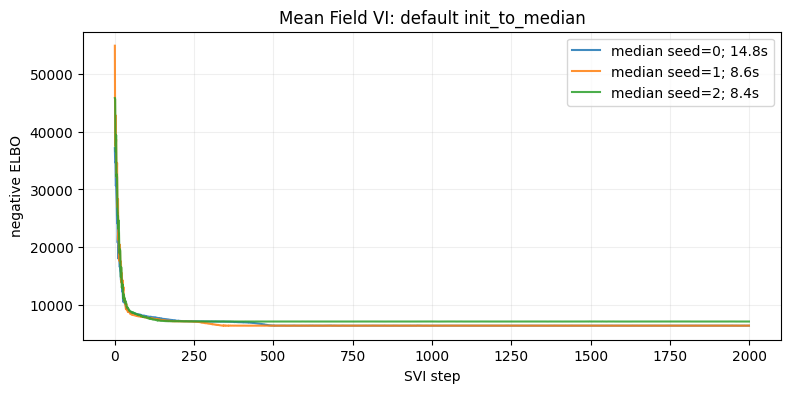

median seed=0: time=14.80s, ARI=0.311


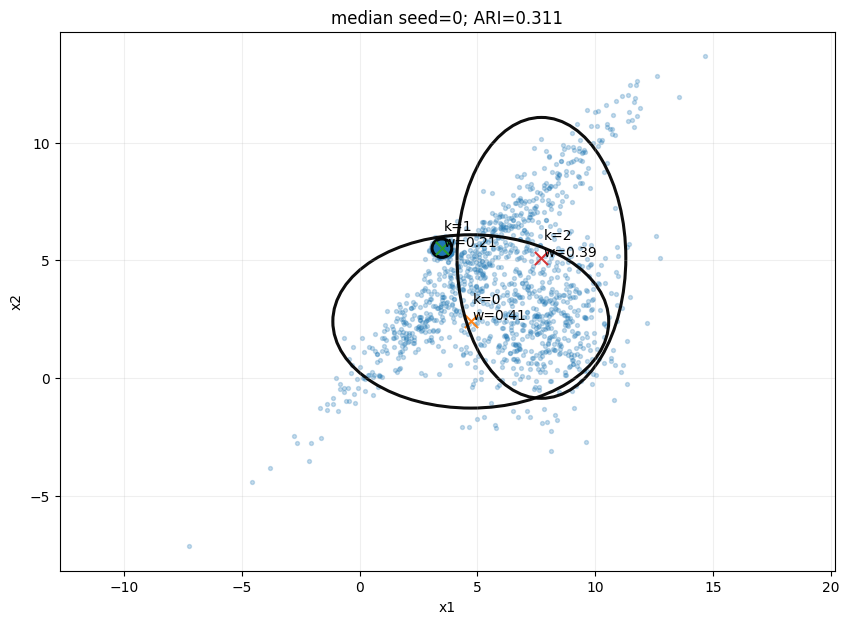

median seed=1: time=8.65s, ARI=0.322


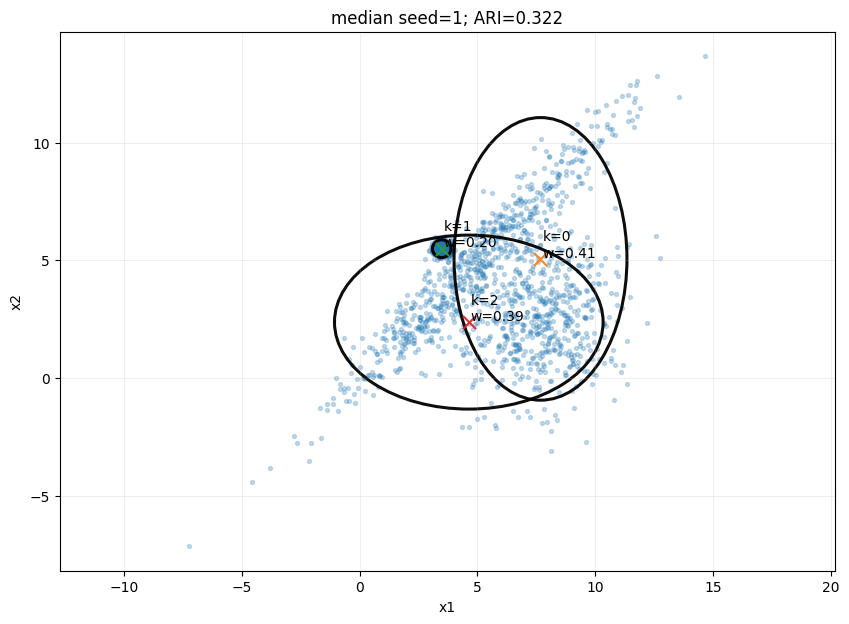

median seed=2: time=8.45s, ARI=0.003


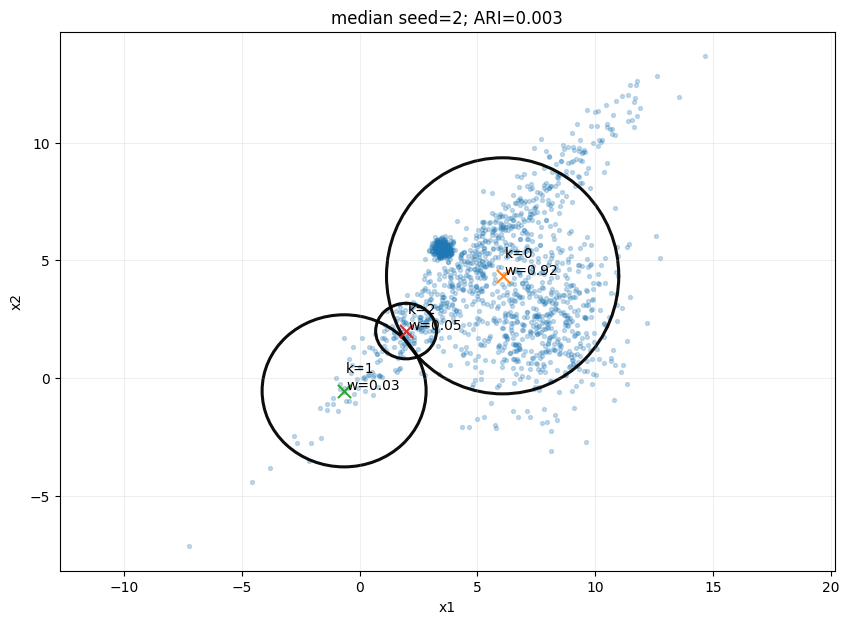

In [7]:
mf_median_runs = {}
for seed in [0, 1, 2]:
    mf_median_runs[f"median seed={seed}"] = run_svi(
        model_mf, AutoDiagonalNormal, data_2d,
        K=3, alpha=1.0, init_strategy="median", seed=seed,
        num_steps=2000, lr=0.03, full_cov=False,
    )

plot_losses(mf_median_runs, "Mean Field VI: default init_to_median")

for name, res in mf_median_runs.items():
    labels_pred = posterior_cluster_labels(data_2d, res["median"], model_type="mf")
    ari = adjusted_rand_score(true_labels.numpy(), labels_pred.numpy())
    print(f"{name}: time={res['elapsed']:.2f}s, ARI={ari:.3f}")
    plot_gmm_ellipses(data_2d, res["median"], model_type="mf", title=f"{name}; ARI={ari:.3f}")


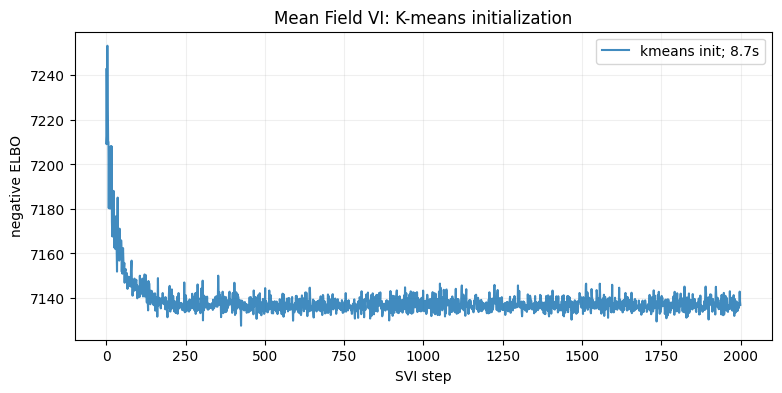

Mean Field + K-means: time=8.75s, ARI=0.028


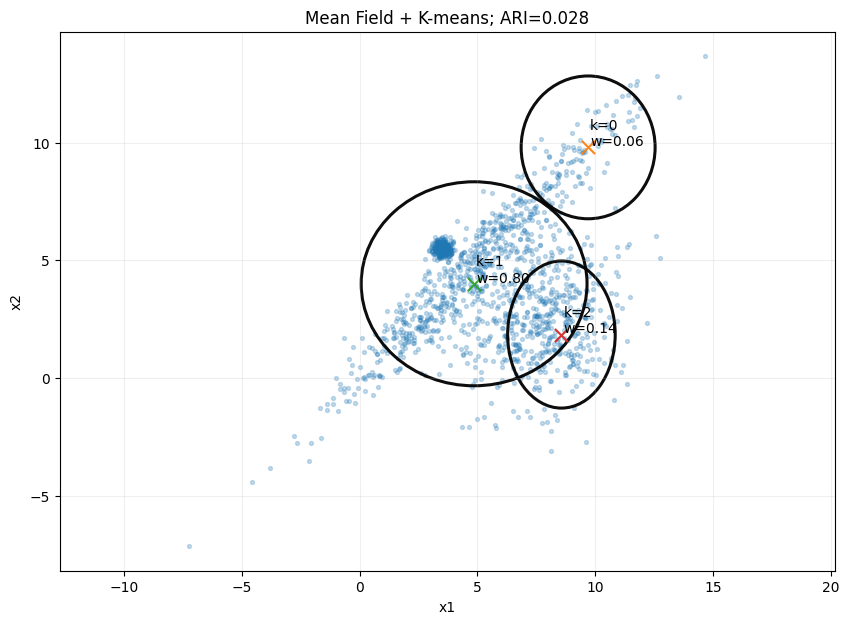

In [8]:
mf_kmeans = run_svi(
    model_mf, AutoDiagonalNormal, data_2d,
    K=3, alpha=1.0, init_strategy="kmeans", seed=42,
    num_steps=2000, lr=0.03, full_cov=False,
)

plot_losses({"kmeans init": mf_kmeans}, "Mean Field VI: K-means initialization")
labels_pred = posterior_cluster_labels(data_2d, mf_kmeans["median"], model_type="mf")
ari = adjusted_rand_score(true_labels.numpy(), labels_pred.numpy())
print(f"Mean Field + K-means: time={mf_kmeans['elapsed']:.2f}s, ARI={ari:.3f}")
plot_gmm_ellipses(data_2d, mf_kmeans["median"], model_type="mf", title=f"Mean Field + K-means; ARI={ari:.3f}")


**Комментарий к 1.1.**

Mean Field VI обычно работает быстро, потому что оптимизирует параметры аппроксимирующего распределения градиентным методом и не строит длинную цепь зависимых сэмплов. Но диагональная ковариация — сильное ограничение для этих данных: вытянутый диагональный кластер B не может быть хорошо описан эллипсом с осями, параллельными координатным осям. Поэтому модель может искать компромисс: завышать дисперсии, неверно разделять B и C или занимать один компонент под часть вытянутого облака.

K-means инициализация помогает избежать плохих локальных минимумов: начальные центры уже находятся рядом с плотными областями данных. Но сама диагональная форма ковариации всё равно остается ограничением модели.


### 1.2 Make VI Great Again: Full Rank VI + полная ковариация

Теперь компоненты смеси имеют полную ковариационную матрицу. Это должно лучше подходить к данным, потому что кластер B вытянут по диагонали. Цена — больше параметров, более сложная геометрия апостериорного распределения и более медленная оптимизация.


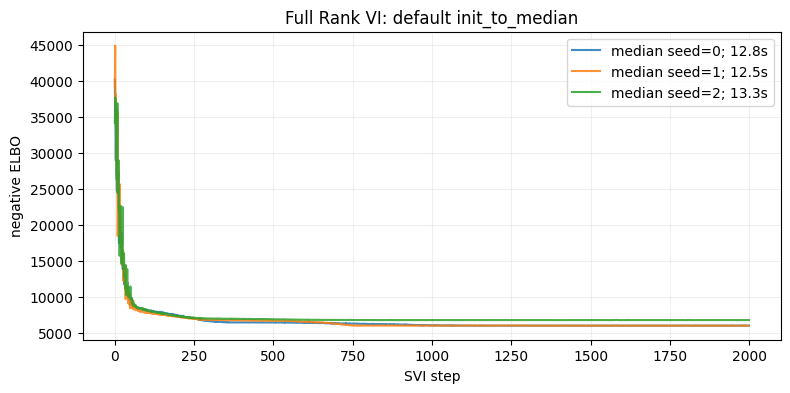

median seed=0: time=12.85s, ARI=0.872


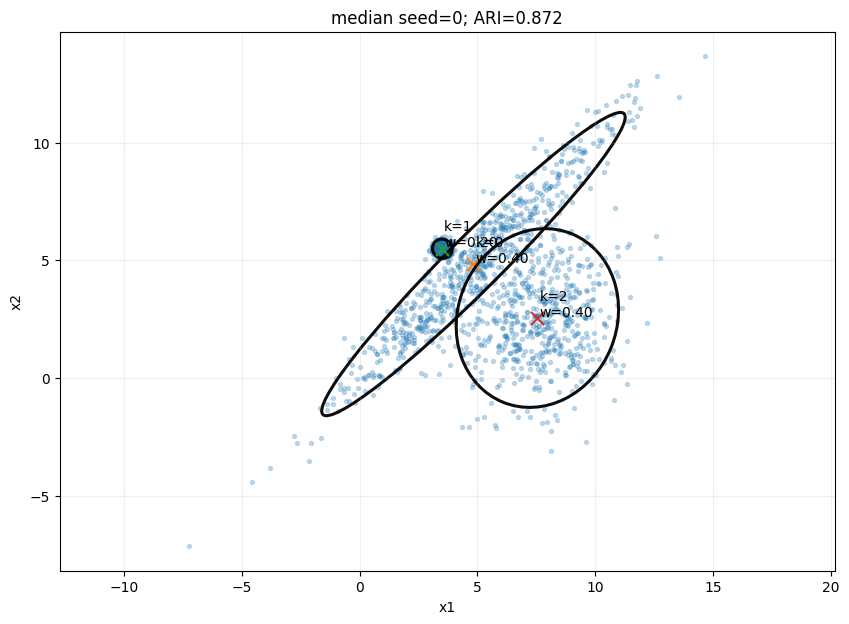

median seed=1: time=12.45s, ARI=0.869


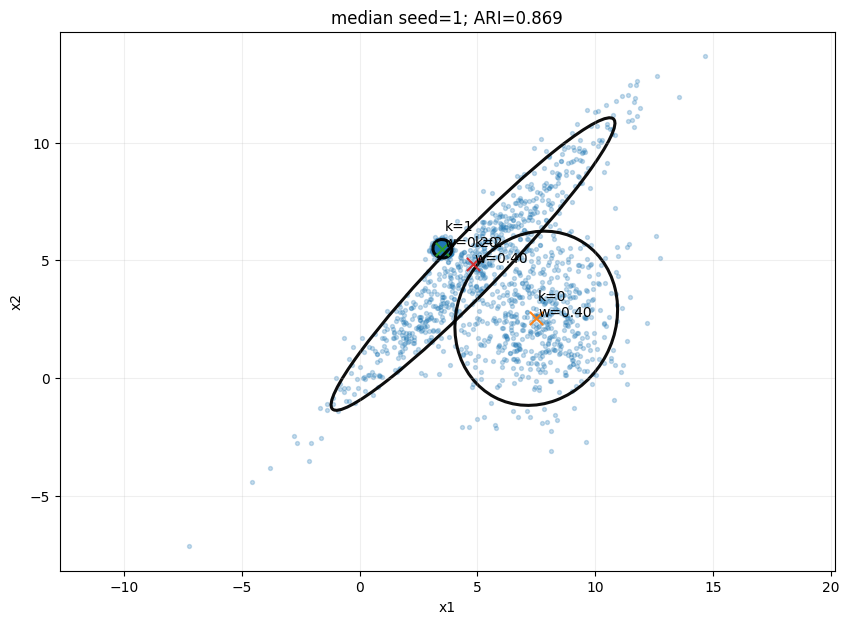

median seed=2: time=13.30s, ARI=0.531


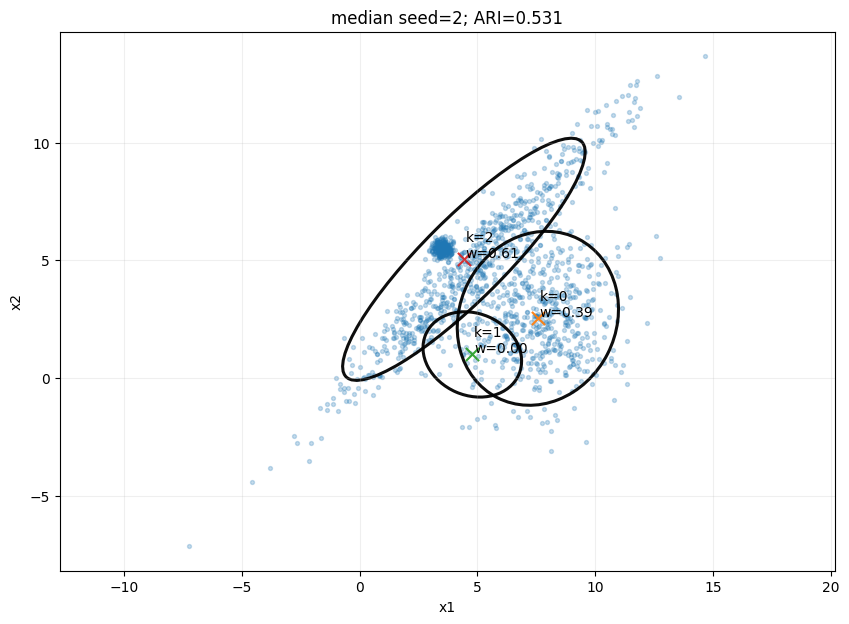

In [9]:
fr_median_runs = {}
for seed in [0, 1, 2]:
    fr_median_runs[f"median seed={seed}"] = run_svi(
        model_fr, AutoMultivariateNormal, data_2d,
        K=3, alpha=1.0, init_strategy="median", seed=seed,
        num_steps=2000, lr=0.02, full_cov=True,
    )

plot_losses(fr_median_runs, "Full Rank VI: default init_to_median")

for name, res in fr_median_runs.items():
    labels_pred = posterior_cluster_labels(data_2d, res["median"], model_type="fr")
    ari = adjusted_rand_score(true_labels.numpy(), labels_pred.numpy())
    print(f"{name}: time={res['elapsed']:.2f}s, ARI={ari:.3f}")
    plot_gmm_ellipses(data_2d, res["median"], model_type="fr", title=f"{name}; ARI={ari:.3f}")


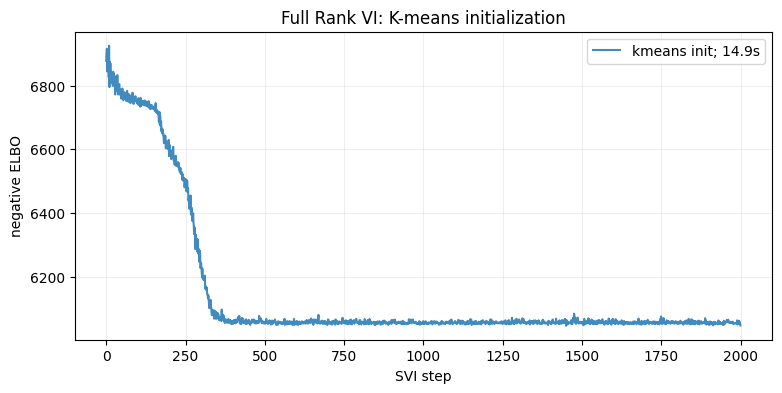

Full Rank + K-means: time=14.88s, ARI=0.871


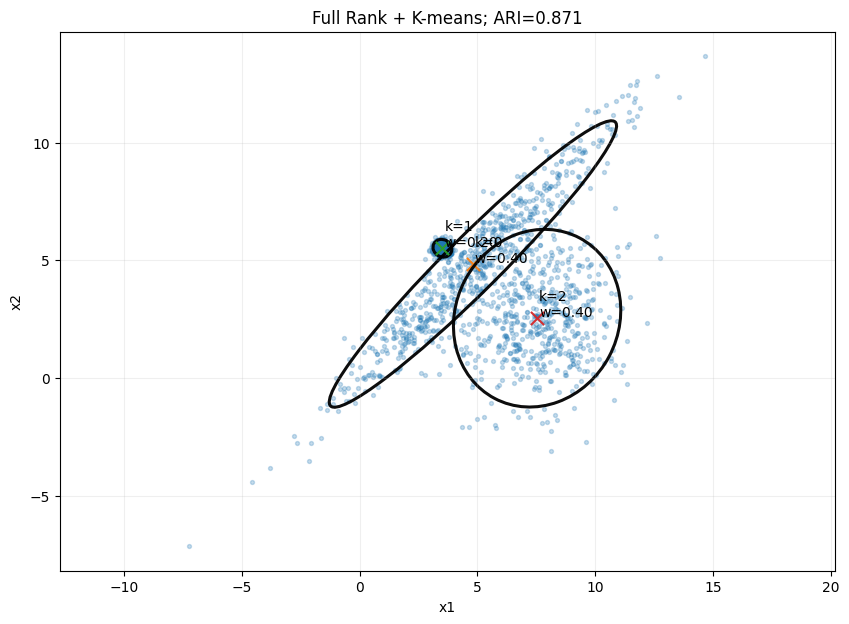

In [10]:
fr_kmeans = run_svi(
    model_fr, AutoMultivariateNormal, data_2d,
    K=3, alpha=1.0, init_strategy="kmeans", seed=42,
    num_steps=2000, lr=0.02, full_cov=True,
)

plot_losses({"kmeans init": fr_kmeans}, "Full Rank VI: K-means initialization")
labels_pred = posterior_cluster_labels(data_2d, fr_kmeans["median"], model_type="fr")
ari = adjusted_rand_score(true_labels.numpy(), labels_pred.numpy())
print(f"Full Rank + K-means: time={fr_kmeans['elapsed']:.2f}s, ARI={ari:.3f}")
plot_gmm_ellipses(data_2d, fr_kmeans["median"], model_type="fr", title=f"Full Rank + K-means; ARI={ari:.3f}")


**Комментарий к 1.2.**

Full Rank модель лучше соответствует структуре данных: она может повернуть эллипс кластера B вдоль диагонали, а не пытаться описывать его диагональной ковариацией. Поэтому адекватность модели должна вырасти: эллипсы становятся ближе к реальной геометрии кластеров.

Однако цена — вычислительная сложность и устойчивость оптимизации. `AutoMultivariateNormal` хранит полную ковариацию для латентных переменных guide, а сама модель содержит `LKJCholesky` для корреляционных матриц компонент. Из-за этого каждая итерация дороже, а задача оптимизации становится чувствительнее к seed и инициализации.


## 2. MCMC: NUTS для универсальной модели

Запускаем NUTS для модели с полной ковариацией и сравниваем `warmup_steps=20` и `warmup_steps=100` при `num_samples=300`.

Важно: MCMC для смеси гауссиан может работать долго, потому что:

- данные большие для HMC/NUTS;
- в модели есть дискретная смесь, маргинализованная через `MixtureSameFamily`;
- есть проблема label switching: компоненты смеси симметричны, поэтому цепи могут переставлять номера кластеров;
- полные ковариации через LKJ усложняют геометрию апостериорного распределения.


In [15]:
from functools import partial
import time

def run_nuts_fast(data, K=3, alpha=1.0, warmup_steps=50, num_samples=150, num_chains=1, seed=42):
    pyro.set_rng_seed(seed)

    conditioned_model = partial(model_fr, K=K, alpha=alpha)

    kernel = NUTS(
        conditioned_model,
        max_tree_depth=6,
        full_mass=False,
        jit_compile=True,
        ignore_jit_warnings=True
    )

    mcmc = MCMC(
        kernel,
        num_samples=num_samples,
        warmup_steps=warmup_steps,
        num_chains=num_chains,
        disable_progbar=False
    )

    start = time.perf_counter()
    mcmc.run(data)
    elapsed = time.perf_counter() - start

    return {
        "mcmc": mcmc,
        "samples": mcmc.get_samples(group_by_chain=True),
        "elapsed": elapsed,
        "K": K,
        "alpha": alpha,
    }

def summarize_rhat(samples):
    from pyro.ops.stats import gelman_rubin
    print("R-hat values:")
    for name, value in samples.items():
        try:
            rhat = gelman_rubin(value)
            print(f"{name:15s}: max={torch.nanmax(rhat).item():.3f}, mean={torch.nanmean(rhat).item():.3f}")
        except Exception as e:
            print(f"{name:15s}: could not compute R-hat ({e})")


def plot_trace(samples, var_name="locs", max_dims=6, title="Trace plot"):
    x = samples[var_name].detach().cpu()
    # shape: chains, draws, ...
    chains, draws = x.shape[0], x.shape[1]
    flat = x.reshape(chains, draws, -1)
    n_dims = min(max_dims, flat.shape[-1])

    plt.figure(figsize=(11, 2.2 * n_dims))
    for d in range(n_dims):
        plt.subplot(n_dims, 1, d + 1)
        for c in range(chains):
            plt.plot(flat[c, :, d], alpha=0.8, label=f"chain {c}" if d == 0 else None)
        plt.ylabel(f"{var_name}[{d}]")
        plt.grid(alpha=0.2)
    plt.suptitle(title)
    if chains > 1:
        plt.legend()
    plt.tight_layout()
    plt.show()


def autocorr_1d(x, max_lag=60):
    x = x.detach().cpu().float()
    x = x - x.mean()
    denom = (x * x).sum().clamp_min(1e-8)
    ac = []
    for lag in range(max_lag + 1):
        ac.append((x[:len(x)-lag] * x[lag:]).sum() / denom)
    return torch.stack(ac)


def plot_autocorr(samples, var_name="locs", max_lag=60, max_dims=4, title="Autocorrelation"):
    x = samples[var_name].detach().cpu()
    chains, draws = x.shape[0], x.shape[1]
    flat = x.reshape(chains, draws, -1)
    n_dims = min(max_dims, flat.shape[-1])

    plt.figure(figsize=(9, 2.2 * n_dims))
    for d in range(n_dims):
        plt.subplot(n_dims, 1, d + 1)
        for c in range(chains):
            ac = autocorr_1d(flat[c, :, d], max_lag=max_lag)
            plt.plot(range(max_lag + 1), ac, alpha=0.8, label=f"chain {c}" if d == 0 else None)
        plt.ylabel(f"{var_name}[{d}]")
        plt.grid(alpha=0.2)
    plt.xlabel("lag")
    plt.suptitle(title)
    if chains > 1:
        plt.legend()
    plt.tight_layout()
    plt.show()


def mcmc_samples_to_median(samples):
    # group_by_chain=True => chains, draws, ...; объединим chains и draws.
    merged = {k: v.reshape(-1, *v.shape[2:]) for k, v in samples.items()}
    return {k: v.median(dim=0).values for k, v in merged.items()}


Sample: 100%|██████████| 120/120 [00:07, 15.47it/s, step size=5.33e-02, acc. prob=0.090]


NUTS warmup=20: time=7.76s
R-hat values:
corr_cholesky  : could not compute R-hat ()
locs           : could not compute R-hat ()
scales         : could not compute R-hat ()
weights        : could not compute R-hat ()


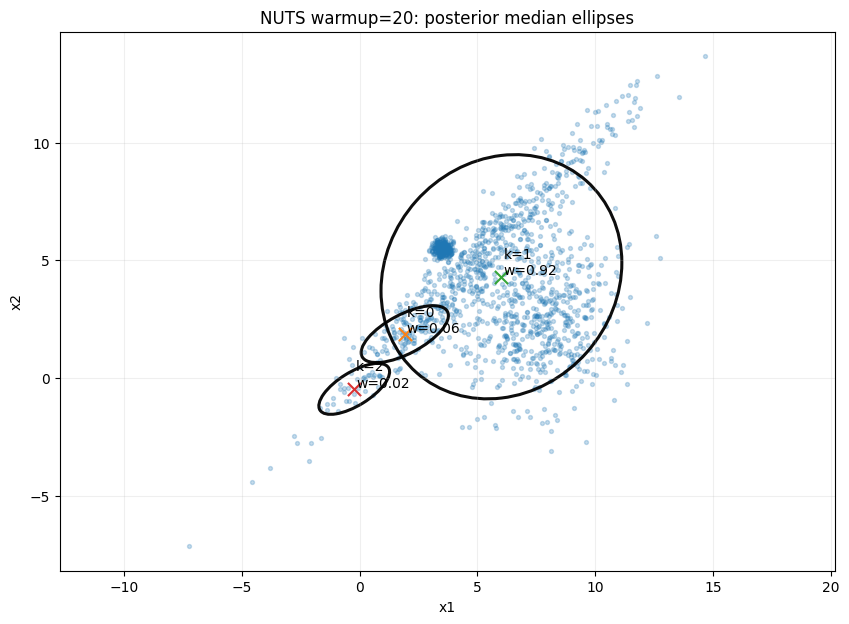

In [17]:
nuts_20 = run_nuts_fast(
    data_2d,
    K=3,
    alpha=1.0,
    warmup_steps=20,
    num_samples=100,
    num_chains=1,   # быстрее; для проверки хватит
    seed=42
)

print(f"NUTS warmup=20: time={nuts_20['elapsed']:.2f}s")

summarize_rhat(nuts_20["samples"])

median_20 = mcmc_samples_to_median(nuts_20["samples"])

plot_gmm_ellipses(
    data_2d,
    median_20,
    model_type="fr",
    title="NUTS warmup=20: posterior median ellipses"
)

Sample: 100%|██████████| 200/200 [00:28,  7.00it/s, step size=6.71e-03, acc. prob=0.892]


NUTS warmup=100: time=28.57s
R-hat values:
corr_cholesky  : could not compute R-hat ()
locs           : could not compute R-hat ()
scales         : could not compute R-hat ()
weights        : could not compute R-hat ()


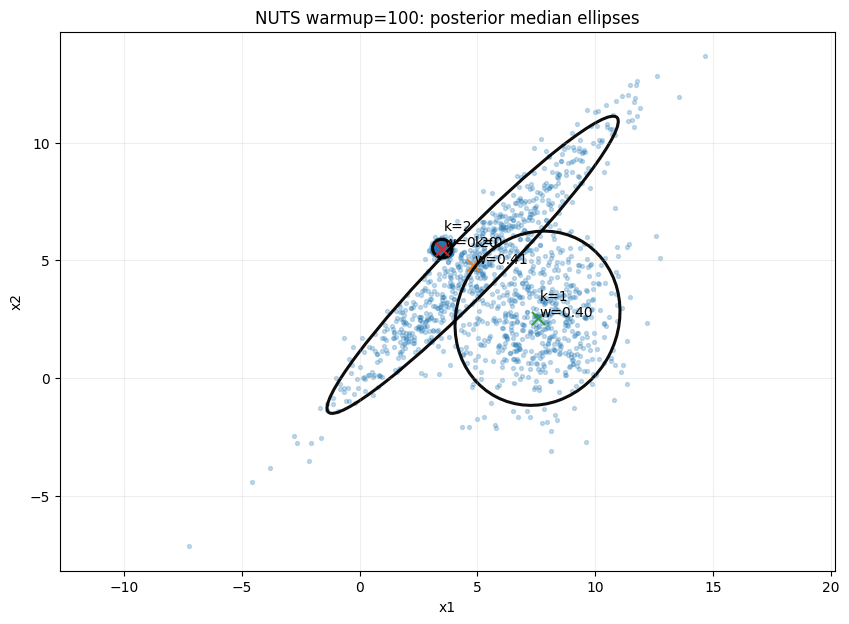

In [18]:
nuts_100 = run_nuts_fast(
    data_2d,
    K=3,
    alpha=1.0,
    warmup_steps=100,
    num_samples=100,
    num_chains=1,
    seed=42
)

print(f"NUTS warmup=100: time={nuts_100['elapsed']:.2f}s")

summarize_rhat(nuts_100["samples"])

median_100 = mcmc_samples_to_median(nuts_100["samples"])

plot_gmm_ellipses(
    data_2d,
    median_100,
    model_type="fr",
    title="NUTS warmup=100: posterior median ellipses"
)

**Комментарий к MCMC.**

При `warmup_steps=20` NUTS часто не успевает хорошо настроить размер шага и массу, поэтому trace plots могут выглядеть хуже, autocorrelation выше, а R-hat дальше от 1.0. При `warmup_steps=100` адаптация должна быть стабильнее: цепи лучше перемешиваются, R-hat обычно ближе к 1.0, а автокорреляция убывает быстрее.

При этом MCMC гораздо дороже VI: вместо одной оптимизации параметров он строит цепи сэмплов, а каждый шаг NUTS требует нескольких вычислений градиента. На больших данных и модели с полной ковариацией это становится особенно заметно.


## 3. Разреживающий Dirichlet prior: автоматический выбор числа кластеров

Теперь зададим избыточное число компонент `K=10`, но используем разреживающий prior:

\[
\text{weights} \sim \text{Dirichlet}(\alpha=0.1)
\]

Идея: если компонент больше, чем нужно, prior с малым `alpha` подталкивает веса части компонент к почти нулевым значениям. Тогда модель может оставить активными только несколько кластеров.


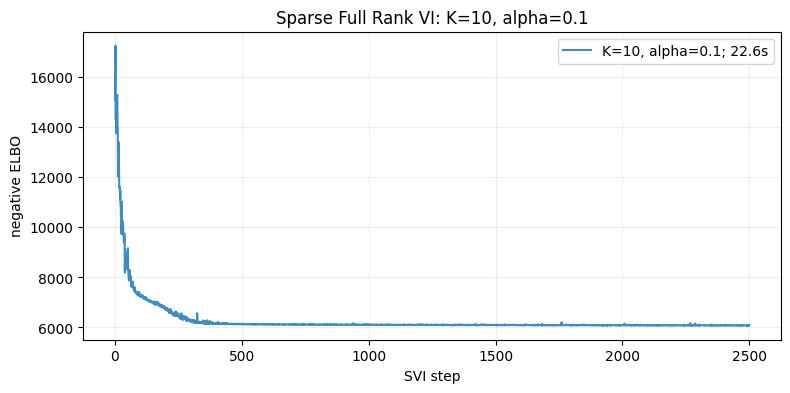

Posterior median weights:
tensor([0.0000, 0.0000, 0.4050, 0.3950, 0.0000, 0.0000, 0.0010, 0.0000, 0.1990,
        0.0000])
Active clusters, weight > 0.05: [2, 3, 8]


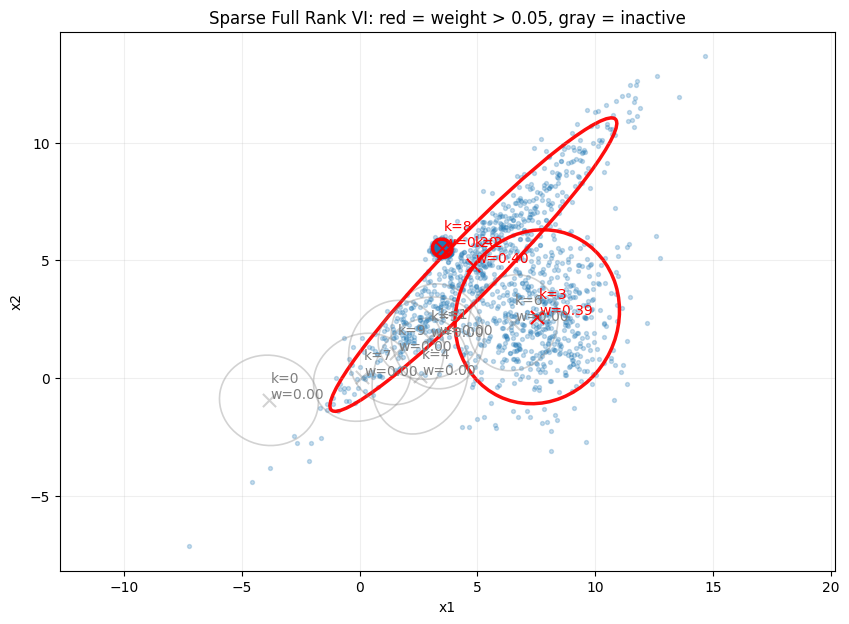

In [19]:
sparse_vi = run_svi(
    model_fr, AutoMultivariateNormal, data_2d,
    K=10, alpha=0.1, init_strategy="median", seed=7,
    num_steps=2500, lr=0.015, full_cov=True,
)

plot_losses({"K=10, alpha=0.1": sparse_vi}, "Sparse Full Rank VI: K=10, alpha=0.1")
weights, locs, covs = params_to_covariances(sparse_vi["median"], model_type="fr")
print("Posterior median weights:")
print(torch.round(weights, decimals=3))
print("Active clusters, weight > 0.05:", torch.where(weights > 0.05)[0].tolist())
plot_gmm_ellipses(
    data_2d, sparse_vi["median"], model_type="fr",
    title="Sparse Full Rank VI: red = weight > 0.05, gray = inactive",
    weight_threshold=0.05,
)


Sample: 100%|██████████| 150/150 [00:40,  3.74it/s, step size=1.71e-02, acc. prob=0.917]

Sparse NUTS K=10 alpha=0.1: time=40.16s
R-hat values:
corr_cholesky  : could not compute R-hat ()
locs           : could not compute R-hat ()
scales         : could not compute R-hat ()
weights        : could not compute R-hat ()


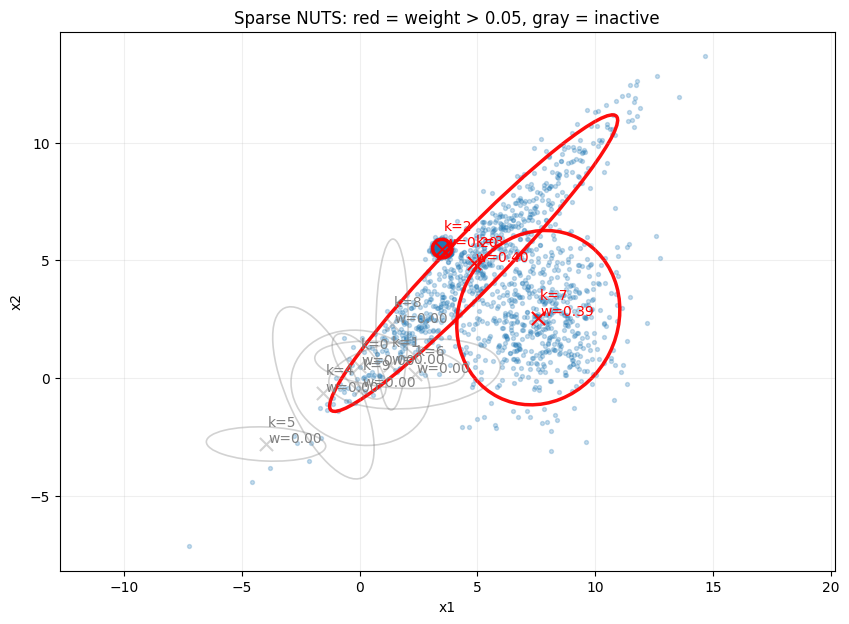

In [20]:
sparse_nuts = run_nuts_fast(
    data_2d,
    K=10,
    alpha=0.1,
    warmup_steps=50,
    num_samples=100,
    num_chains=1,
    seed=7
)

print(f"Sparse NUTS K=10 alpha=0.1: time={sparse_nuts['elapsed']:.2f}s")

summarize_rhat(sparse_nuts["samples"])

sparse_nuts_median = mcmc_samples_to_median(sparse_nuts["samples"])

plot_gmm_ellipses(
    data_2d,
    sparse_nuts_median,
    model_type="fr",
    title="Sparse NUTS: red = weight > 0.05, gray = inactive",
    weight_threshold=0.05,
)

## Ответы на вопросы

### Почему VI работает на порядки быстрее MCMC на больших данных, но может давать смещенную оценку дисперсии?

VI формулирует вывод как задачу оптимизации: мы выбираем семейство распределений `q(z)` и ищем параметры, максимизирующие ELBO. Поэтому вместо длинной цепи зависимых сэмплов VI делает градиентные шаги и часто сходится намного быстрее.

Но скорость достигается за счет аппроксимации. Например, `AutoDiagonalNormal` предполагает независимость латентных переменных в guide, а значит не может полностью описать корреляции апостериорного распределения. Кроме того, минимизация `KL(q || p)` часто ведет себя mode-seeking: аппроксимация концентрируется около одной моды и может недооценивать хвосты и дисперсию. Поэтому VI может давать смещенные оценки uncertainty, особенно для сложных мультимодальных моделей вроде Gaussian Mixture Model.

### Является ли K-means для инициализации байесовской модели честным подходом?

Да, если использовать K-means только как способ инициализации, а не как подмену байесовского вывода. Это похоже на empirical Bayes или data-informed initialization: данные помогают выбрать стартовую точку оптимизации, но итоговые параметры всё равно оцениваются вероятностной моделью.

Однако важно явно указать это в методологии. Такой подход делает процедуру менее «чисто априорной», потому что начальные значения зависят от данных. Если сравниваются методы inference, нужно применять одинаково честные условия: например, сравнивать default init и K-means init отдельно, не смешивая их результаты.

### Как sparsity prior Dirichlet(alpha=0.1) помогает автоматически определить количество кластеров?

Dirichlet с малым `alpha < 1` предпочитает разреженные векторы весов: часть компонент получает большие веса, а остальные — веса около нуля. Поэтому можно задать избыточное число компонент, например `K=10`, и затем считать активными только компоненты с весом выше порога, например `weight > 0.05`.

Это не полностью автоматическое «доказательство» числа кластеров, потому что результат зависит от prior, порога, инициализации и качества inference. Но practically это хороший способ дать модели возможность выключить лишние компоненты.

### Почему NUTS при K=10 стал работать ещё медленнее?

При увеличении `K` растет число латентных параметров: веса, средние, масштабы и корреляционные матрицы для каждой компоненты. Для NUTS это особенно дорого, потому что каждый сэмпл требует построения траектории Hamiltonian dynamics и многократных вычислений градиента. Кроме того, mixture models имеют симметрию перестановки компонент: компоненты можно поменять местами без изменения likelihood. При `K=10` эта проблема label switching и мультимодальность становятся сильнее, поэтому цепям сложнее перемешиваться, R-hat может ухудшаться, а autocorrelation — расти.
